In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

In [91]:
# Potencial en cada lado (incertidumbre 0.001)

E2 = 7.49
E4 = 4.99
E6 = 2.493

# 30 Voltajes distinto en 30 puntos (incertidumbre 0.001)

V_30 = [3.099, 2.967, 3.113, 3.087, 2.773, 3.010, 2.585, 2.329, 2.760, 2.570, 2.243,
        1.589, 1.898, 0.851, 0.733, 0.004, -0.274, -0.276, -0.375, -1.154, -2.15, -1.601, 
        -1.857, -2.088, -2.038, -3.418, -3.053, -2.72, -2.494, -2.824
        ]

#posición de carga positiva y negativa (x,y) en metros

plus = [0.095, 0.084]
minus = [0.181, 0.083]

#coordenadas / Matriz de coordenadas de V_30

d_x0 = [1.3, 1.9, 2.5, 3.2, 5.3, 6.0, 7.0, 7.7, 7.8, 8.9, 10.1, 10.6, 12.0, 12.9, 13.0, 14.0,
       14.4, 14.5, 15.0, 17.3, 17.5, 17.5, 18.6, 20.0, 20.6, 21.2, 22.3, 23.5, 24.9, 25.5]

d_x0 = np.array(d_x0) #En metros porque las medidas están en cm
d_x = d_x0 / 100

d_y0 = [7.7, 12.5, 7.3, 10.7, 13.9, 4.8, 2.3, 15.4, 4.2, 12.4, 3.8, 14.8, 7.1, 1.8, 11.0, 8.4, 
       7.4, 16.2, 3.4, 0.6, 12.2, 15.3, 3.0, 17.0, 1.4, 9.5, 6.6, 13.1, 3.4, 6.2]

d_y0 = np.array(d_y0) #En metros porque las medidas están en cm
d_y = d_y0 / 100
#Creación de la matriz de 30x2 para tener las coordenadas juntas.

d_coord = []

for i in range(len(d_x)):
    d_coord.append([d_x[i], d_y[i]])

for i, punto in enumerate(d_coord):
    # punto[0] es x, punto[1] es y
    print(f"Punto {i+1:02d}: $({punto[0]:.3f}, {punto[1]:.3f})$")

Punto 01: $(0.013, 0.077)$
Punto 02: $(0.019, 0.125)$
Punto 03: $(0.025, 0.073)$
Punto 04: $(0.032, 0.107)$
Punto 05: $(0.053, 0.139)$
Punto 06: $(0.060, 0.048)$
Punto 07: $(0.070, 0.023)$
Punto 08: $(0.077, 0.154)$
Punto 09: $(0.078, 0.042)$
Punto 10: $(0.089, 0.124)$
Punto 11: $(0.101, 0.038)$
Punto 12: $(0.106, 0.148)$
Punto 13: $(0.120, 0.071)$
Punto 14: $(0.129, 0.018)$
Punto 15: $(0.130, 0.110)$
Punto 16: $(0.140, 0.084)$
Punto 17: $(0.144, 0.074)$
Punto 18: $(0.145, 0.162)$
Punto 19: $(0.150, 0.034)$
Punto 20: $(0.173, 0.006)$
Punto 21: $(0.175, 0.122)$
Punto 22: $(0.175, 0.153)$
Punto 23: $(0.186, 0.030)$
Punto 24: $(0.200, 0.170)$
Punto 25: $(0.206, 0.014)$
Punto 26: $(0.212, 0.095)$
Punto 27: $(0.223, 0.066)$
Punto 28: $(0.235, 0.131)$
Punto 29: $(0.249, 0.034)$
Punto 30: $(0.255, 0.062)$


In [63]:
np.sqrt((minus[0] - d_coord[25][0])**2 + (minus[1] - d_coord[25][1])**2)

0.03324154027718932

In [ ]:
#Distancias hacia la carga positiva

dp = []

for i in range(len(d_coord)):
    dp.append(np.sqrt((plus[0] - d_coord[i][0])**2 + (plus[1] - d_coord[i][1])**2))

#Distancias hacia la carga negativa

dn = []

for i in range(len(d_coord)):
    dn.append(np.sqrt((minus[0] - d_coord[i][0])**2 + (minus[1] - d_coord[i][1])**2))

dn


5300.0

In [104]:
#Cálculo de la carga que generó dicho voltaje:
k = 8.99 * 10**9 #Constante k
Cargas = []

for i in range(len(d_coord)):
    Cargas.append((V_30[i] * dp[i] * dn[i]) / (k * (dn[i] - dp[i])))

Media = np.mean(Cargas)
Desviacion = np.std(Cargas)

#Error

error = (Desviacion) * 100 / (np.sqrt(30) * Media) #La fórmula del pdf está mal falta dividir para la media

for q in Cargas:
    # Imprime el valor en notación científica seguido de &
    # El parámetro end=" " evita que se salte de línea automáticamente
    print(f"{q:.4e} &", end=" ")

error

5.5578e-11 & 5.8882e-11 & 4.4881e-11 & 4.1449e-11 & 4.2295e-11 & 2.7954e-11 & 3.9696e-11 & 4.3952e-11 & 2.3526e-11 & 1.9322e-11 & 2.3401e-11 & 3.3203e-11 & 1.0881e-11 & 6.5017e-11 & 1.4543e-11 & -2.0592e-13 & 4.8646e-12 & 4.2328e-11 & 1.0997e-11 & 3.3324e-11 & 1.7019e-11 & 3.7351e-11 & 2.2130e-11 & 6.0144e-11 & 3.7747e-11 & 1.7624e-11 & 2.3692e-11 & 4.2798e-11 & 4.8206e-11 & 4.6138e-11 & 

9.232507696470247

In [100]:
#Errores para cada carga:
#Error V = 0.001
#Error distancia = 0.0007

Errores = []

for i in range(len(Cargas)):
    valor = np.sqrt(((dp[i] * dn[i] * 0.001)/((dn[i] - dp[i]) * k))**2 + 
                    ((V_30[i] * dn[i]**2 * 0.0007)/(((dn[i] - dp[i]))**2 * k))**2 + ((V_30[i] * dp[i]**2 * 0.0007)/(((dn[i] - dp[i]))**2 * k))**2)
    Errores.append(valor)

for q in Errores:
    # Imprime el valor en notación científica seguido de &
    # El parámetro end=" " evita que se salte de línea automáticamente
    print(f"{q:.4e} &", end=" ")

9.5252e-13 & 1.0207e-12 & 8.2805e-13 & 7.9378e-13 & 8.7299e-13 & 6.5623e-13 & 9.1508e-13 & 1.0521e-12 & 6.2326e-13 & 5.6606e-13 & 7.3694e-13 & 1.1264e-12 & 5.0473e-13 & 7.2471e-12 & 1.1001e-12 & 7.2858e-14 & 4.3364e-13 & 7.2145e-12 & 7.0725e-13 & 1.1268e-12 & 5.5521e-13 & 1.2150e-12 & 6.0418e-13 & 1.4971e-12 & 8.5609e-13 & 5.1918e-13 & 5.6787e-13 & 8.3491e-13 & 8.6434e-13 & 8.2222e-13 & 

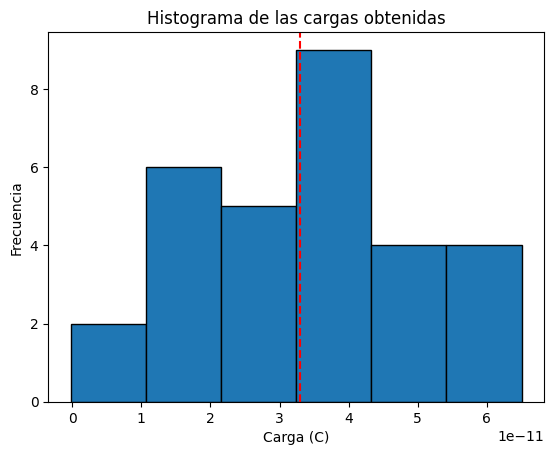

In [ ]:
#Histograma

plt.hist(Cargas, bins=6, edgecolor = "black")   # puedes ajustar el número de bins (recomendable 6 para 30 datos)
plt.axvline(Media, linestyle="--", color = "red") #Media ubicada en el gráfico
plt.xlabel("Carga (C)")
plt.ylabel("Frecuencia")
plt.title("Histograma de las cargas obtenidas")
plt.show()